In [252]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported!")



Libraries imported!


### Load the dataset

In [253]:
data = pd.read_csv("employee_attrition.csv")
print(f"Dataset loaded successfully!")

Dataset loaded successfully!


### Data understanding

In [254]:
data.head()

,EmployeeID,Age,Gender,Department,MonthlyIncome,YearsAtCompany,OverTime,JobSatisfaction,WorkLifeBalance,TrainingTimesLastYear,Attrition
0,1,38.0,Male,HR,0.000000,0.40,No,2.0,3,0.5,No
1,2,33.0,Male,HR,0.075385,0.25,No,2.0,2,0.3,No
2,3,40.0,Female,Sales,0.136375,0.70,No,1.0,2,0.5,No
3,4,47.0,Male,HR,0.174409,0.60,No,3.0,3,0.2,No
4,5,33.0,Female,IT,0.153290,0.20,No,NaN,3,0.1,Yes


In [255]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8400 entries, 0 to 8399
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   EmployeeID             8400 non-null   int64  
 1   Age                    7561 non-null   float64
 2   Gender                 8400 non-null   object 
 3   Department             8400 non-null   object 
 4   MonthlyIncome          7556 non-null   float64
 5   YearsAtCompany         8400 non-null   float64
 6   OverTime               8400 non-null   object 
 7   JobSatisfaction        7567 non-null   float64
 8   WorkLifeBalance        8400 non-null   int64  
 9   TrainingTimesLastYear  8400 non-null   float64
 10  Attrition              8400 non-null   object 
dtypes: float64(5), int64(2), object(4)
memory usage: 722.0+ KB


In [256]:
data.describe().round(2)

,EmployeeID,Age,MonthlyIncome,YearsAtCompany,JobSatisfaction,WorkLifeBalance,TrainingTimesLastYear
count,8400.00,7561.00,7556.00,8400.00,7567.00,8400.00,8400.00
mean,3994.27,34.66,0.19,0.30,2.19,2.54,0.23
std,2311.56,7.63,0.16,0.20,1.02,0.98,0.15
min,1.00,22.00,0.00,0.00,1.00,1.00,0.00
25%,1987.75,29.00,0.06,0.15,1.00,2.00,0.10
50%,3990.50,34.00,0.17,0.30,2.00,3.00,0.20
75%,6002.00,40.00,0.29,0.45,3.00,3.00,0.30
max,8000.00,60.00,1.00,1.00,4.00,4.00,1.00


### Remove irrelevant columns/features/variables

In [257]:
data.drop("EmployeeID", axis=1, inplace=True)

In [258]:
data.head()

,Age,Gender,Department,MonthlyIncome,YearsAtCompany,OverTime,JobSatisfaction,WorkLifeBalance,TrainingTimesLastYear,Attrition
0,38.0,Male,HR,0.000000,0.40,No,2.0,3,0.5,No
1,33.0,Male,HR,0.075385,0.25,No,2.0,2,0.3,No
2,40.0,Female,Sales,0.136375,0.70,No,1.0,2,0.5,No
3,47.0,Male,HR,0.174409,0.60,No,3.0,3,0.2,No
4,33.0,Female,IT,0.153290,0.20,No,NaN,3,0.1,Yes


### Checking for missing value

In [259]:
data.isnull().sum()

Age                      839
Gender                     0
Department                 0
MonthlyIncome            844
YearsAtCompany             0
OverTime                   0
JobSatisfaction          833
WorkLifeBalance            0
TrainingTimesLastYear      0
Attrition                  0
dtype: int64

In [260]:
#check in percentage
data.isnull().mean() *100

Age                       9.988095
Gender                    0.000000
Department                0.000000
MonthlyIncome            10.047619
YearsAtCompany            0.000000
OverTime                  0.000000
JobSatisfaction           9.916667
WorkLifeBalance           0.000000
TrainingTimesLastYear     0.000000
Attrition                 0.000000
dtype: float64

In [261]:
import missingno as msn

<Axes: >

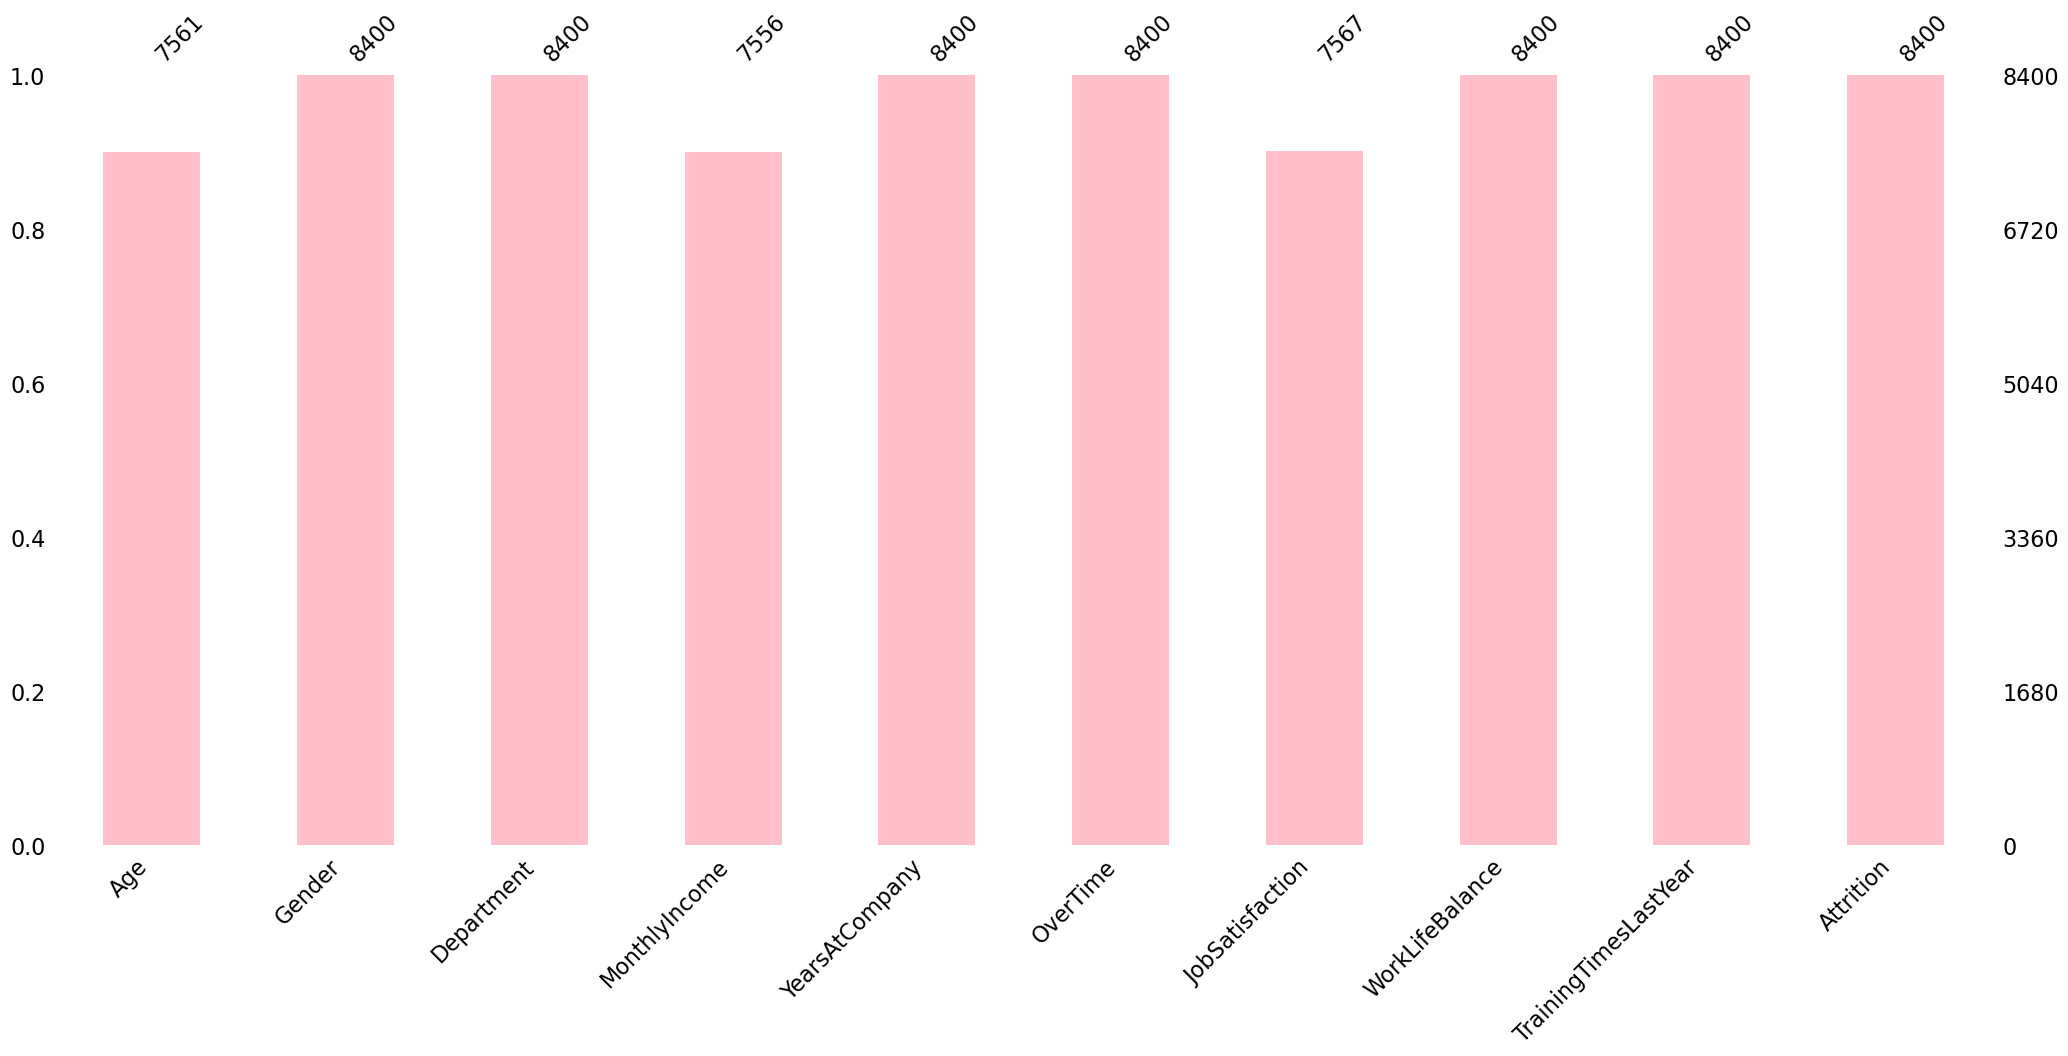

In [262]:
msn.bar(data, color="pink")

<Axes: >

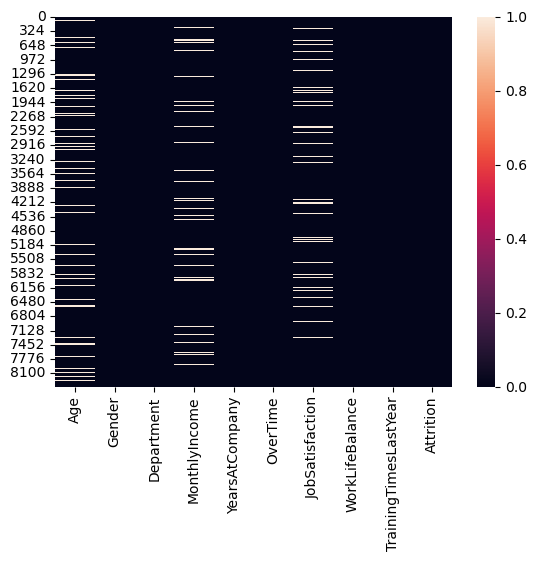

In [263]:
sns.heatmap(data.isnull())

In [264]:
data['Age'] = data['Age'].fillna(data['Age'].median())
data['MonthlyIncome'] = data['MonthlyIncome'].fillna(data['MonthlyIncome'].median())

In [265]:
data['JobSatisfaction'] = data['JobSatisfaction'].fillna(
    data['JobSatisfaction'].mode().iloc[0]
)

In [266]:
data.isnull().sum()

Age                      0
Gender                   0
Department               0
MonthlyIncome            0
YearsAtCompany           0
OverTime                 0
JobSatisfaction          0
WorkLifeBalance          0
TrainingTimesLastYear    0
Attrition                0
dtype: int64

<Axes: >

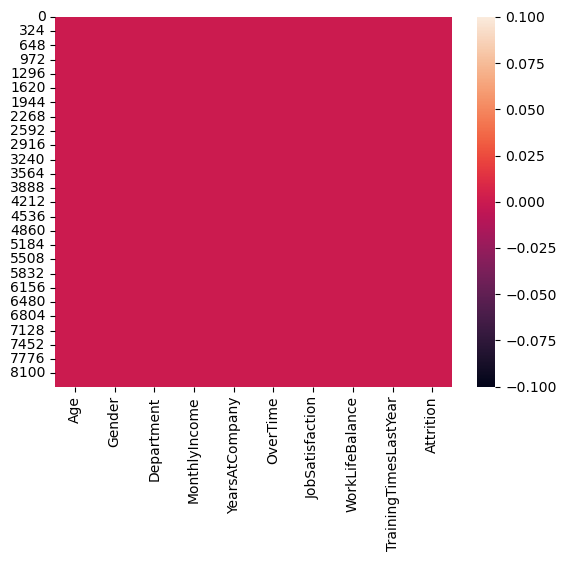

In [267]:
sns.heatmap(data.isnull())

### Handling Duplicate Data

In [268]:
data.duplicated().sum()

np.int64(408)

In [269]:
int(data.duplicated().sum())

408

In [270]:
len(data)

8400

### Remove Duplicates

In [271]:
data = data.drop_duplicates().reset_index(drop=True)

In [272]:
len(data)

7992

### Handling Outlier in Dataset

In [273]:
# check for outliers in numerical columns
numerical_columns = data.select_dtypes(include="number")

In [274]:
numerical_columns

,Age,MonthlyIncome,YearsAtCompany,JobSatisfaction,WorkLifeBalance,TrainingTimesLastYear
0,38.0,0.000000,0.40,2.0,3,0.5
1,33.0,0.075385,0.25,2.0,2,0.3
2,40.0,0.136375,0.70,1.0,2,0.5
3,47.0,0.174409,0.60,3.0,3,0.2
4,33.0,0.153290,0.20,1.0,3,0.1
...,...,...,...,...,...,...
7987,52.0,0.334159,0.80,1.0,3,0.3
7988,37.0,0.000000,0.15,4.0,3,0.1
7989,28.0,0.109883,0.10,3.0,3,0.3
7990,34.0,0.092938,0.65,2.0,4,0.1


In [275]:
len(numerical_columns.columns)

6

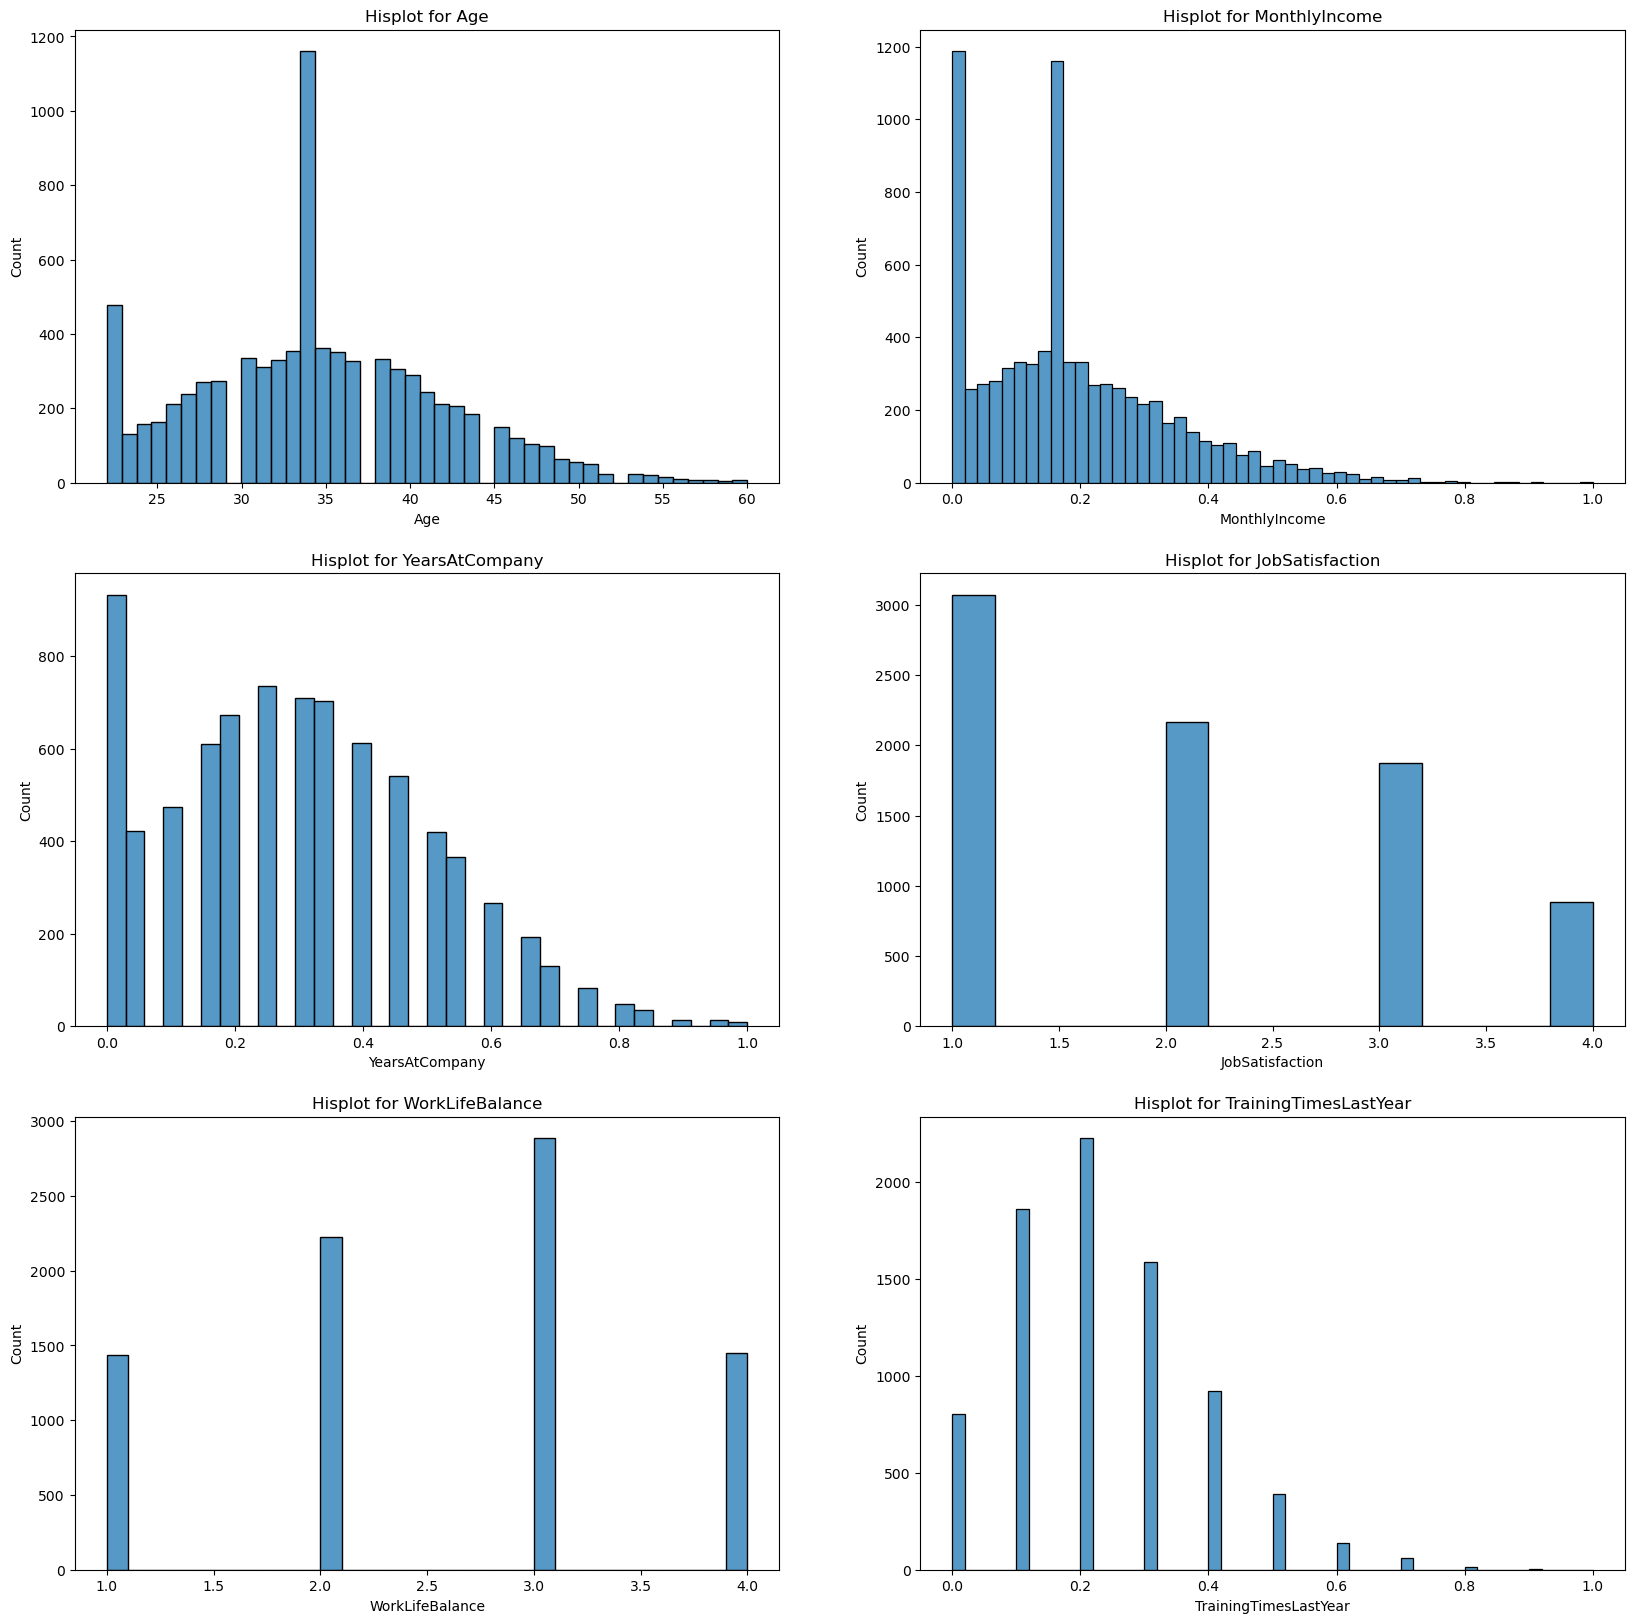

In [276]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize = (20,20))
ax = ax.flatten()

for idx, col in enumerate(numerical_columns) :
    sns.histplot(data[col],ax=ax[idx])
    ax[idx].set_title(f"Hisplot for {col}")
    plt.show

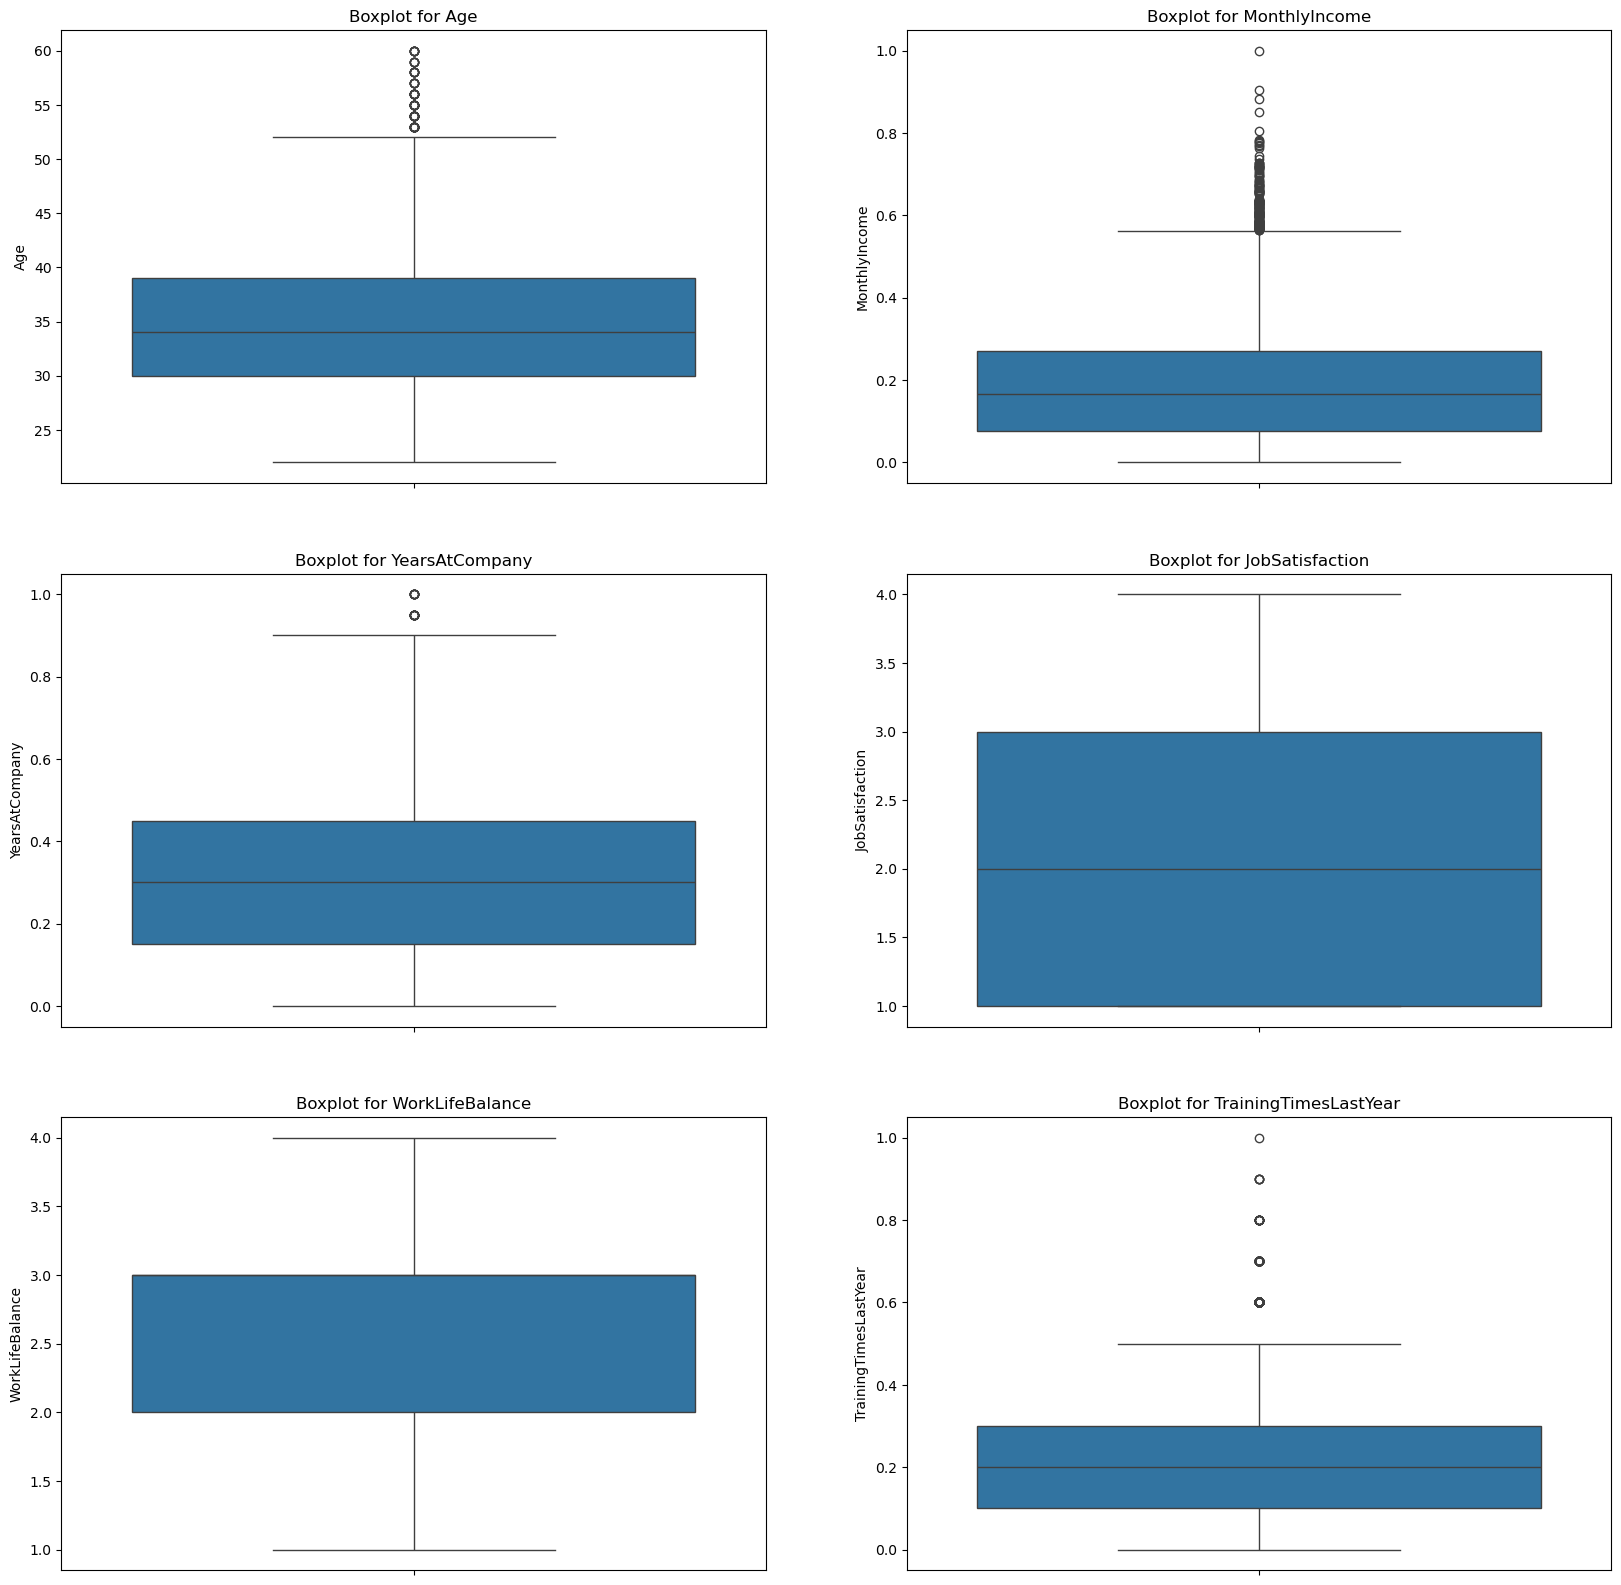

In [277]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize = (20,20))
ax = ax.flatten()

for idx, col in enumerate(numerical_columns) :
    sns.boxplot(data[col],ax=ax[idx])
    ax[idx].set_title(f"Boxplot for {col}")
    plt.show

### let remove outlier on affected column using IQR

In [278]:
affected_column = ["Age","MonthlyIncome", "YearsAtCompany", "TrainingTimesLastYear"]

In [279]:
q1 = data[affected_column].quantile(0.25)
q3 = data[affected_column].quantile(0.75)

In [280]:
iqr = q3 - q1

In [281]:
lower_bound = q1 -(1.5 * iqr)
upper_bound = q3 +(1.5 * iqr)

In [282]:
lower_bound

Age                      16.500000
MonthlyIncome            -0.215109
YearsAtCompany           -0.300000
TrainingTimesLastYear    -0.200000
dtype: float64

In [283]:
upper_bound

Age                      52.500000
MonthlyIncome             0.563573
YearsAtCompany            0.900000
TrainingTimesLastYear     0.600000
dtype: float64

In [284]:
data[affected_column] = data[affected_column].clip(lower=lower_bound, upper=upper_bound, axis=1)

### let verified that the dataset is free from outlier

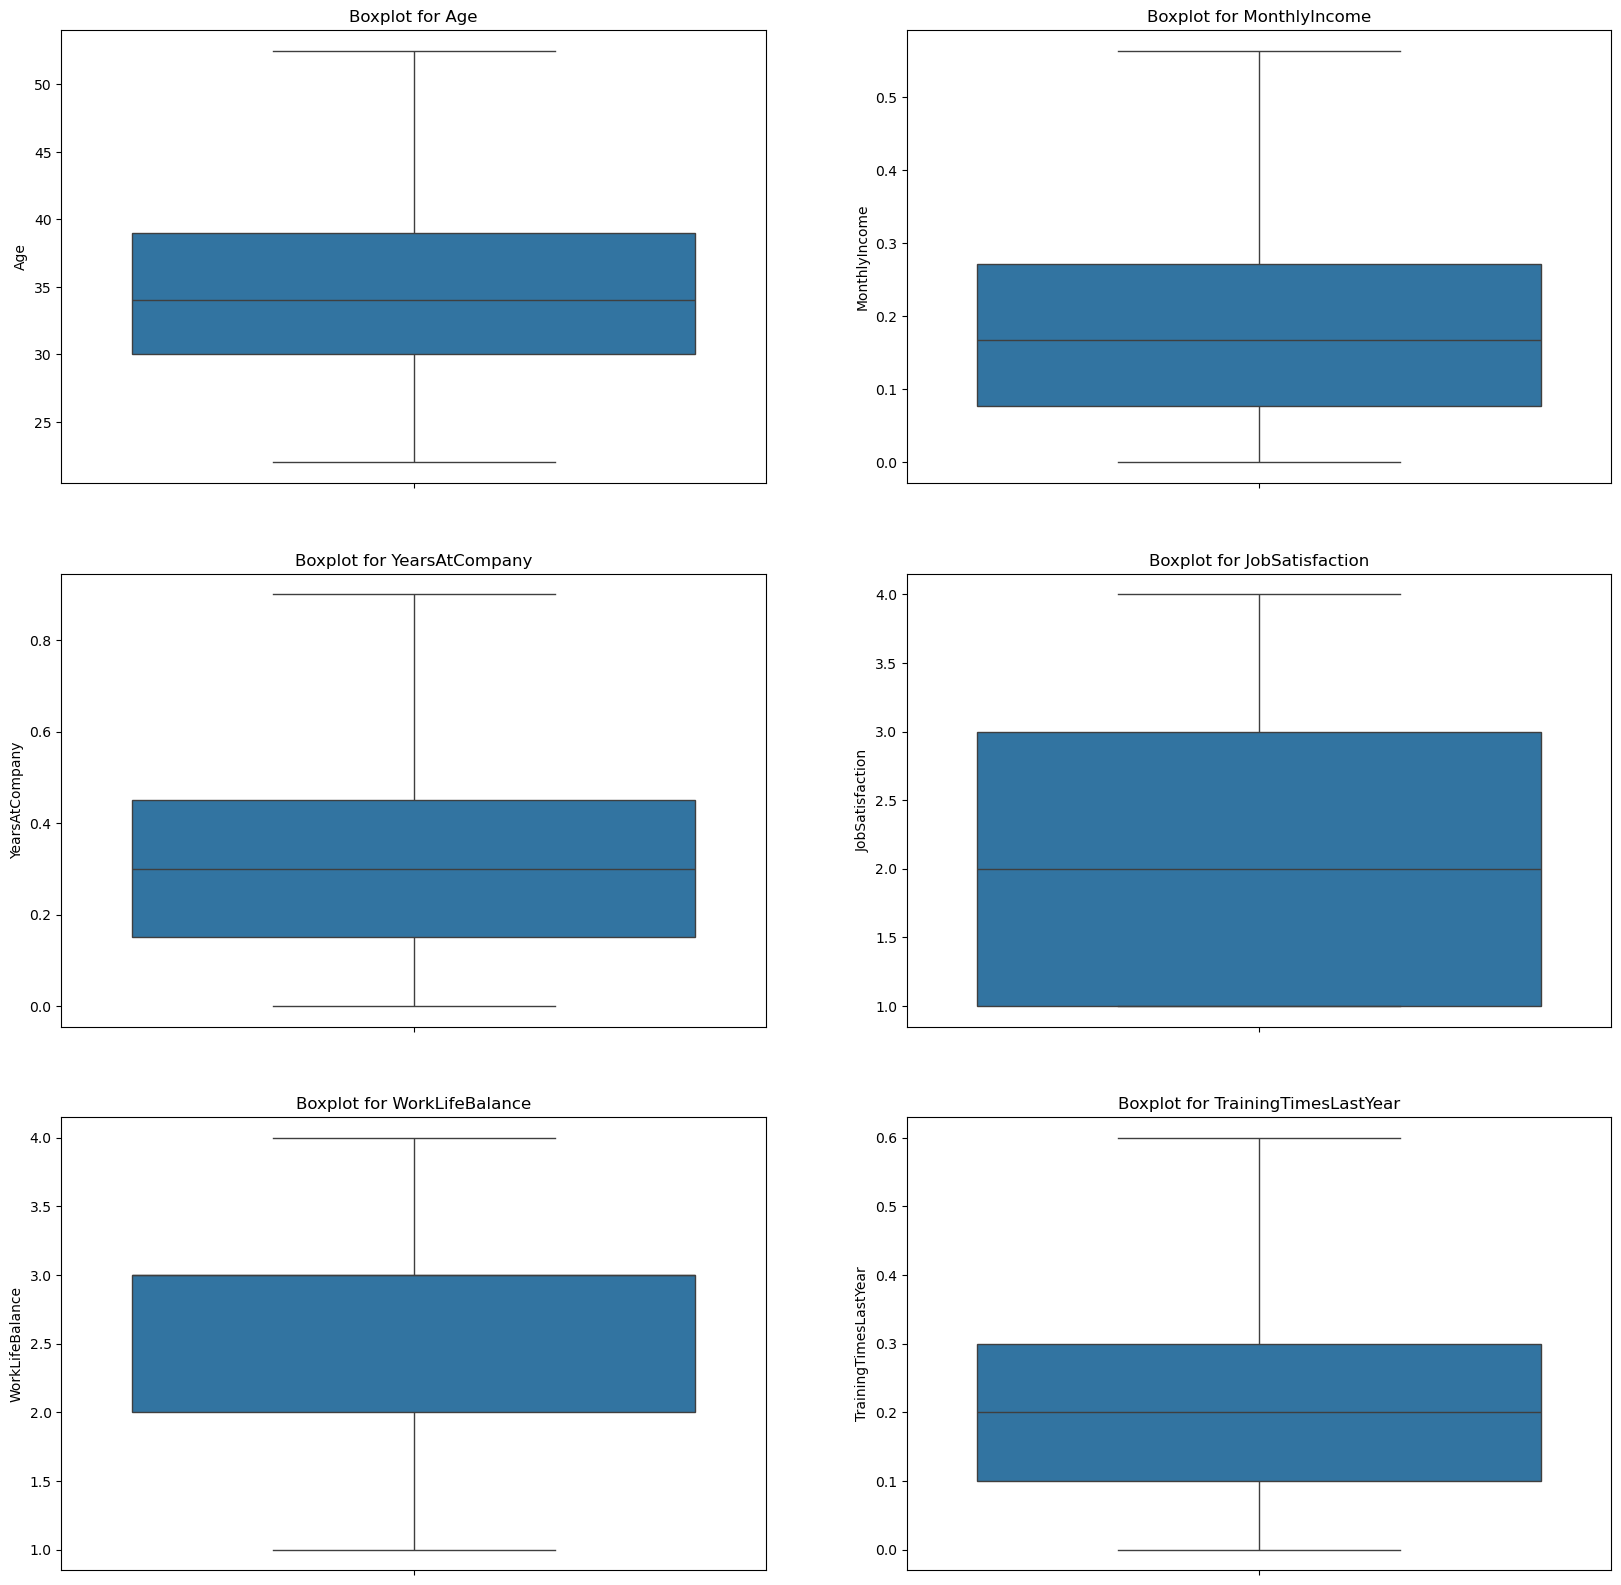

In [285]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize = (20,20))
ax = ax.flatten()

for idx, col in enumerate(numerical_columns) :
    sns.boxplot(data[col],ax=ax[idx])
    ax[idx].set_title(f"Boxplot for {col}")
    plt.show

### Encode categorical variables
#such as Gender, Department, OverTime and Attrition into numerical format

In [286]:
data.head()

,Age,Gender,Department,MonthlyIncome,YearsAtCompany,OverTime,JobSatisfaction,WorkLifeBalance,TrainingTimesLastYear,Attrition
0,38.0,Male,HR,0.000000,0.40,No,2.0,3,0.5,No
1,33.0,Male,HR,0.075385,0.25,No,2.0,2,0.3,No
2,40.0,Female,Sales,0.136375,0.70,No,1.0,2,0.5,No
3,47.0,Male,HR,0.174409,0.60,No,3.0,3,0.2,No
4,33.0,Female,IT,0.153290,0.20,No,1.0,3,0.1,Yes


In [287]:
from sklearn.preprocessing import LabelEncoder

In [288]:
# INITAILIZE THE ENCODER
encoder = LabelEncoder()

## two step approach:
## 1. Fit
## 2. Transform

In [289]:
data["Gender"].value_counts()

Gender
Female    4036
Male      3956
Name: count, dtype: int64

In [290]:
encoder.fit(data["Gender"])

LabelEncoder()

In [291]:
encoder.transform(data["Gender"])

array([1, 1, 0, ..., 0, 1, 0], shape=(7992,))

In [292]:
encoder.fit_transform(data["Gender"])

array([1, 1, 0, ..., 0, 1, 0], shape=(7992,))

In [293]:
data["Gender"] = encoder.fit_transform(data["Gender"])
data["OverTime"] = encoder.fit_transform(data["OverTime"])
data["Attrition"] = encoder.fit_transform(data["Attrition"])

In [294]:
data.head(20)

,Age,Gender,Department,MonthlyIncome,YearsAtCompany,OverTime,JobSatisfaction,WorkLifeBalance,TrainingTimesLastYear,Attrition
0,38.0,1,HR,0.000000,0.40,0,2.0,3,0.5,0
1,33.0,1,HR,0.075385,0.25,0,2.0,2,0.3,0
2,40.0,0,Sales,0.136375,0.70,0,1.0,2,0.5,0
3,47.0,1,HR,0.174409,0.60,0,3.0,3,0.2,0
4,33.0,0,IT,0.153290,0.20,0,1.0,3,0.1,1
5,33.0,0,HR,0.093426,0.25,0,1.0,4,0.6,0
6,47.0,0,Sales,0.025425,0.70,0,2.0,2,0.0,0
7,41.0,0,HR,0.092883,0.45,0,4.0,1,0.2,1
8,31.0,0,Sales,0.126271,0.25,1,1.0,1,0.6,0
9,39.0,1,Sales,0.000000,0.45,0,3.0,2,0.4,0


In [295]:
# one Hot Encodings

In [296]:
data = pd.get_dummies(data, columns=["Department"], dtype=int)

In [297]:
data.head()

,Age,Gender,MonthlyIncome,YearsAtCompany,OverTime,JobSatisfaction,WorkLifeBalance,TrainingTimesLastYear,Attrition,Department_Finance,Department_HR,Department_IT,Department_Operations,Department_Sales
0,38.0,1,0.000000,0.40,0,2.0,3,0.5,0,0,1,0,0,0
1,33.0,1,0.075385,0.25,0,2.0,2,0.3,0,0,1,0,0,0
2,40.0,0,0.136375,0.70,0,1.0,2,0.5,0,0,0,0,0,1
3,47.0,1,0.174409,0.60,0,3.0,3,0.2,0,0,1,0,0,0
4,33.0,0,0.153290,0.20,0,1.0,3,0.1,1,0,0,1,0,0


### Scale of Numerical Features
##### scale numerical columns to bring them to a similar range, which we improve the model performance

In [298]:
num_cols_to_scale = ["Age","MonthlyIncome","YearsAtCompany","TrainingTimesLastYear"]

- Standard Scaler - Normal or Slightly Skewed Distribution
- MinMax Scaler - Uniform Distribution
- Robust Scaler - Heavenly skewed distribution

In [299]:
from sklearn.preprocessing import StandardScaler

In [300]:
# initialize the Scaler

In [301]:
scaler = StandardScaler()

In [302]:
data[num_cols_to_scale] = scaler.fit_transform(data[num_cols_to_scale])

In [303]:
data.head()

,Age,Gender,MonthlyIncome,YearsAtCompany,OverTime,JobSatisfaction,WorkLifeBalance,TrainingTimesLastYear,Attrition,Department_Finance,Department_HR,Department_IT,Department_Operations,Department_Sales
0,0.479168,1,-1.301722,0.503833,0,2.0,3,1.900458,0,0,1,0,0,0
1,-0.221194,1,-0.778837,-0.232387,0,2.0,2,0.519124,0,0,1,0,0,0
2,0.759312,0,-0.355796,1.976274,0,1.0,2,1.900458,0,0,0,0,0,1
3,1.739818,1,-0.091983,1.485460,0,3.0,3,-0.171543,0,0,1,0,0,0
4,-0.221194,0,-0.238470,-0.477794,0,1.0,3,-0.862210,1,0,0,1,0,0


### Check Class Distribution
#### Assess the balance of the target variable (Attrition) to determine if need to handle the class imbalance

In [304]:
data["Attrition"].value_counts()

Attrition
0    5957
1    2035
Name: count, dtype: int64

In [305]:
data["Attrition"].value_counts(normalize=True)*100

Attrition
0    74.537037
1    25.462963
Name: proportion, dtype: float64

<Axes: xlabel='Attrition', ylabel='count'>

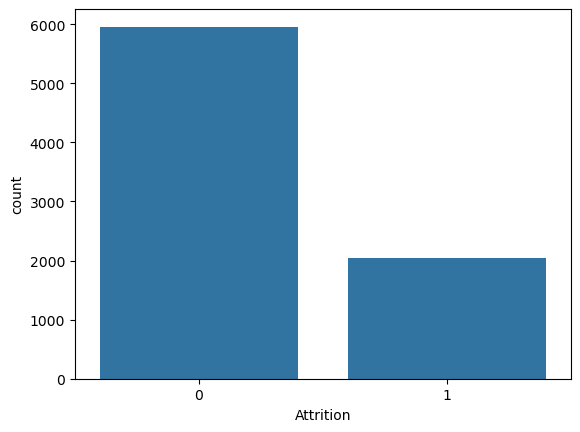

In [306]:
sns.countplot(x=data["Attrition"])

### Handling Class Inbalance
#### Technique to address class inbalance
- Resampling:
  - Oversampling the minority class using techniques like SMOTE ( Synthetic Minority Oversampling Technique)
  - Undersampling the majority class to balance proportions
- Class Weights:
  - Add weights to the classes in the loss function during model training to penalize misclassifications of the minority class.
- Evaluation Metrics:
  - Use metrics like precision, Recall, F1-Score, or ROC-AUC instead of just Accuracy.

In [307]:
!pip install imbalanced-learn

In [308]:
from imblearn.over_sampling import SMOTE

In [309]:
# Separate the features from the Target

In [310]:
x=data.drop("Attrition", axis=1)
y=data["Attrition"]

In [311]:
x.head()

,Age,Gender,MonthlyIncome,YearsAtCompany,OverTime,JobSatisfaction,WorkLifeBalance,TrainingTimesLastYear,Department_Finance,Department_HR,Department_IT,Department_Operations,Department_Sales
0,0.479168,1,-1.301722,0.503833,0,2.0,3,1.900458,0,1,0,0,0
1,-0.221194,1,-0.778837,-0.232387,0,2.0,2,0.519124,0,1,0,0,0
2,0.759312,0,-0.355796,1.976274,0,1.0,2,1.900458,0,0,0,0,1
3,1.739818,1,-0.091983,1.485460,0,3.0,3,-0.171543,0,1,0,0,0
4,-0.221194,0,-0.238470,-0.477794,0,1.0,3,-0.862210,0,0,1,0,0


In [312]:
y.head()

0    0
1    0
2    0
3    0
4    1
Name: Attrition, dtype: int64

In [313]:
smote = SMOTE(random_state=42)

In [314]:
x_resampled, y_resampled = smote.fit_resample(x, y)

In [315]:
y_resampled.value_counts()

Attrition
0    5957
1    5957
Name: count, dtype: int64

In [316]:
y_resampled.value_counts(normalize=True)*100

Attrition
0    50.0
1    50.0
Name: proportion, dtype: float64

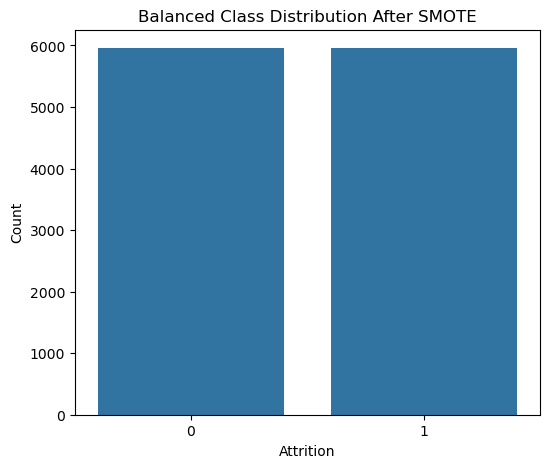

In [317]:
plt.figure(figsize=(6,5))

sns.countplot(x=y_resampled)

plt.title("Balanced Class Distribution After SMOTE")
plt.xlabel("Attrition")
plt.ylabel("Count")

# Save image
plt.savefig("smote_balanced_distribution.png", bbox_inches="tight")

plt.show()

In [318]:
resampled_data = pd.DataFrame(x_resampled, columns=x.columns)

In [319]:
resampled_data.head()

,Age,Gender,MonthlyIncome,YearsAtCompany,OverTime,JobSatisfaction,WorkLifeBalance,TrainingTimesLastYear,Department_Finance,Department_HR,Department_IT,Department_Operations,Department_Sales
0,0.479168,1,-1.301722,0.503833,0,2.0,3,1.900458,0,1,0,0,0
1,-0.221194,1,-0.778837,-0.232387,0,2.0,2,0.519124,0,1,0,0,0
2,0.759312,0,-0.355796,1.976274,0,1.0,2,1.900458,0,0,0,0,1
3,1.739818,1,-0.091983,1.485460,0,3.0,3,-0.171543,0,1,0,0,0
4,-0.221194,0,-0.238470,-0.477794,0,1.0,3,-0.862210,0,0,1,0,0


In [320]:
resampled_data["Attrition"] = y_resampled

In [321]:
resampled_data.head()

,Age,Gender,MonthlyIncome,YearsAtCompany,OverTime,JobSatisfaction,WorkLifeBalance,TrainingTimesLastYear,Department_Finance,Department_HR,Department_IT,Department_Operations,Department_Sales,Attrition
0,0.479168,1,-1.301722,0.503833,0,2.0,3,1.900458,0,1,0,0,0,0
1,-0.221194,1,-0.778837,-0.232387,0,2.0,2,0.519124,0,1,0,0,0,0
2,0.759312,0,-0.355796,1.976274,0,1.0,2,1.900458,0,0,0,0,1,0
3,1.739818,1,-0.091983,1.485460,0,3.0,3,-0.171543,0,1,0,0,0,0
4,-0.221194,0,-0.238470,-0.477794,0,1.0,3,-0.862210,0,0,1,0,0,1


### Final Dataset Cleaned and ready for to be saved

In [322]:
resampled_data.to_csv('cleaned_employee_attrition_balanced.csv', index=False)

In [323]:
df = pd.read_csv('cleaned_employee_attrition_balanced.csv')

In [324]:
df["Attrition"].value_counts()

Attrition
0    5957
1    5957
Name: count, dtype: int64

### DATA SPLITTING
##### We'LL split cleaned dataset into training and testing sets, ensuring the target variable's distribution is representative in both.

In [325]:
from sklearn.model_selection import train_test_split

In [326]:
# splitting the data into 80% for training and 20% for testing
x_train, x_test, y_train, y_test = train_test_split(x_resampled, y_resampled, test_size=0.2, random_state=42)


In [327]:
print(f"Training data size {len(x_train)}")
print(f"Test data size {len(x_test)}")

Training data size 9531
Test data size 2383


In [328]:
y_train.value_counts(normalize=True) * 100

Attrition
0    50.068199
1    49.931801
Name: proportion, dtype: float64

In [329]:
y_test.value_counts(normalize=True) * 100

Attrition
1    50.272765
0    49.727235
Name: proportion, dtype: float64

### Model selection
#### We'ii train multiple classification models to find the best one for predicting attrition.

### Logistic Regression

In [330]:
from sklearn.linear_model import LogisticRegression

In [331]:
# model initialization
model = LogisticRegression(random_state=42)

In [332]:
# model training
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [333]:
# predict on the test set
y_pred = model.predict(x_test)

In [334]:
y_pred[:5]

array([0, 1, 0, 0, 0])

In [335]:
y_test[:5]

3995    0
7474    1
7300    1
3148    0
747     0
Name: Attrition, dtype: int64

In [336]:
print(y_test[:5])

3995    0
7474    1
7300    1
3148    0
747     0
Name: Attrition, dtype: int64


In [337]:
from sklearn.metrics import classification_report, confusion_matrix

In [338]:
report = classification_report(y_test, y_pred)
matrix = confusion_matrix(y_test, y_pred)

In [339]:
print("Logistic Regression Classification Report")
print(report)

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.54      0.58      0.56      1185
           1       0.55      0.51      0.53      1198

    accuracy                           0.54      2383
   macro avg       0.54      0.54      0.54      2383
weighted avg       0.54      0.54      0.54      2383



In [340]:
y_test.value_counts()

Attrition
1    1198
0    1185
Name: count, dtype: int64

In [341]:
len(y_test)

2383

### RANDOM FOREST MODEL

In [342]:
from sklearn.ensemble import RandomForestClassifier

In [343]:
# model initialization
rf_model = RandomForestClassifier(random_state=42, class_weight={0:1, 1:3} )
# model training
rf_model.fit(x_train, y_train)
# predict on the test set
y_pred = rf_model.predict(x_test)
report = classification_report(y_test, y_pred)
matrix = confusion_matrix(y_test, y_pred)
print("Logistic Regression Classification Report")
print(report)

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.79      0.89      0.83      1185
           1       0.87      0.76      0.81      1198

    accuracy                           0.82      2383
   macro avg       0.83      0.82      0.82      2383
weighted avg       0.83      0.82      0.82      2383



In [344]:
y_pred[:5]

array([0, 1, 0, 0, 0])

In [345]:
y_test[:5]

3995    0
7474    1
7300    1
3148    0
747     0
Name: Attrition, dtype: int64

In [346]:
# model initialization
rf_model = RandomForestClassifier(random_state=42, class_weight="balanced" )
# model training
rf_model.fit(x_train, y_train)
# predict on the test set
y_pred = rf_model.predict(x_test)
report = classification_report(y_test, y_pred)
matrix = confusion_matrix(y_test, y_pred)
print("Random Forest Classifier Classification Report")
print(report)

Random Forest Classifier Classification Report
              precision    recall  f1-score   support

           0       0.78      0.88      0.83      1185
           1       0.86      0.76      0.81      1198

    accuracy                           0.82      2383
   macro avg       0.82      0.82      0.82      2383
weighted avg       0.82      0.82      0.82      2383



In [347]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [348]:
# model initialization
gb_model = GradientBoostingClassifier(random_state=42, )
# model training
gb_model.fit(x_train, y_train)
# predict on the test set
y_pred = gb_model.predict(x_test)
report = classification_report(y_test, y_pred)
matrix = confusion_matrix(y_test, y_pred)
print("Gradient Boosting Classifier Classification Report")
print(report)

Gradient Boosting Classifier Classification Report
              precision    recall  f1-score   support

           0       0.70      0.97      0.81      1185
           1       0.95      0.59      0.73      1198

    accuracy                           0.78      2383
   macro avg       0.83      0.78      0.77      2383
weighted avg       0.83      0.78      0.77      2383



In [349]:
!pip install xgboost

In [350]:
from xgboost import XGBClassifier

In [351]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, class_weight="balanced"),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight="balanced"),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Ada Boost': AdaBoostClassifier(random_state=42),
    'SVC': SVC(random_state=42, class_weight="balanced"),
    'KNeighbors Classifier': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    'XGBoost': XGBClassifier(eval_metric="mlogloss")
}

In [352]:
models.items()

dict_items([('Logistic Regression', LogisticRegression(class_weight='balanced', random_state=42)), ('Random Forest', RandomForestClassifier(class_weight='balanced', random_state=42)), ('Gradient Boosting', GradientBoostingClassifier(random_state=42)), ('Ada Boost', AdaBoostClassifier(random_state=42)), ('SVC', SVC(class_weight='balanced', random_state=42)), ('KNeighbors Classifier', KNeighborsClassifier()), ('Decision Tree', DecisionTreeClassifier(class_weight='balanced', random_state=42)), ('XGBoost', XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_thresh

Training Logistic Regression...
Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.54      0.58      0.56      1185
           1       0.55      0.51      0.53      1198

    accuracy                           0.54      2383
   macro avg       0.54      0.54      0.54      2383
weighted avg       0.54      0.54      0.54      2383



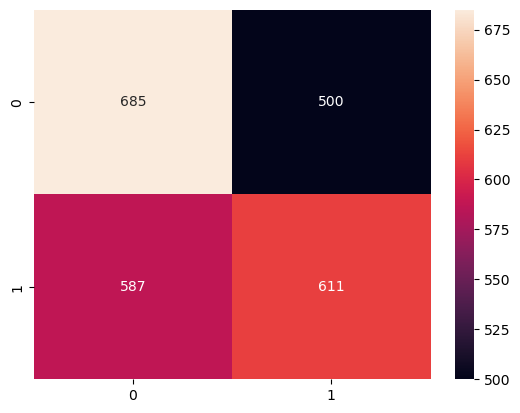

Training Random Forest...
Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.78      0.88      0.83      1185
           1       0.86      0.76      0.81      1198

    accuracy                           0.82      2383
   macro avg       0.82      0.82      0.82      2383
weighted avg       0.82      0.82      0.82      2383



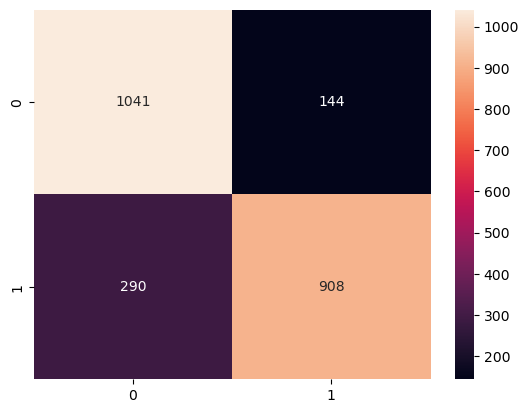

Training Gradient Boosting...
Gradient Boosting Classification Report
              precision    recall  f1-score   support

           0       0.70      0.97      0.81      1185
           1       0.95      0.59      0.73      1198

    accuracy                           0.78      2383
   macro avg       0.83      0.78      0.77      2383
weighted avg       0.83      0.78      0.77      2383



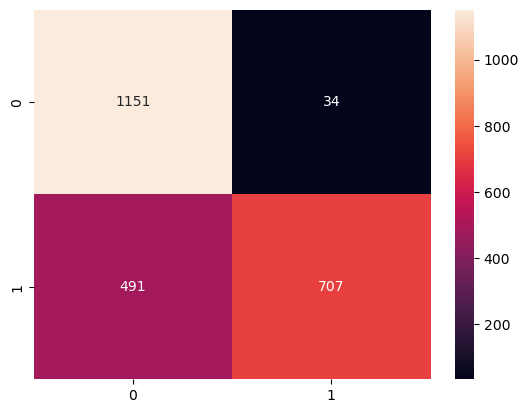

Training Ada Boost...
Ada Boost Classification Report
              precision    recall  f1-score   support

           0       0.62      0.70      0.65      1185
           1       0.66      0.57      0.61      1198

    accuracy                           0.63      2383
   macro avg       0.64      0.64      0.63      2383
weighted avg       0.64      0.63      0.63      2383



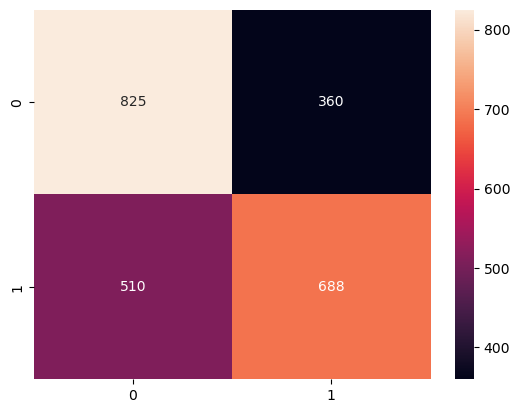

Training SVC...
SVC Classification Report
              precision    recall  f1-score   support

           0       0.61      0.57      0.59      1185
           1       0.60      0.64      0.62      1198

    accuracy                           0.60      2383
   macro avg       0.60      0.60      0.60      2383
weighted avg       0.60      0.60      0.60      2383



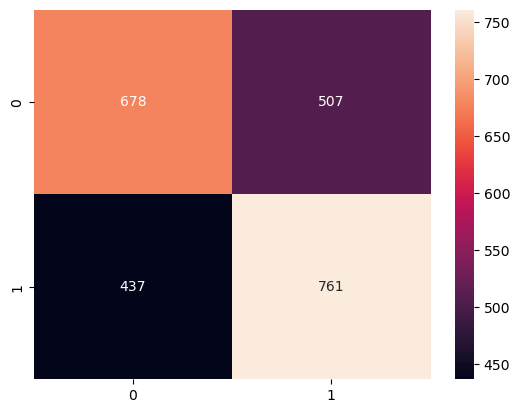

Training KNeighbors Classifier...
KNeighbors Classifier Classification Report
              precision    recall  f1-score   support

           0       0.75      0.55      0.64      1185
           1       0.65      0.82      0.73      1198

    accuracy                           0.69      2383
   macro avg       0.70      0.69      0.68      2383
weighted avg       0.70      0.69      0.68      2383



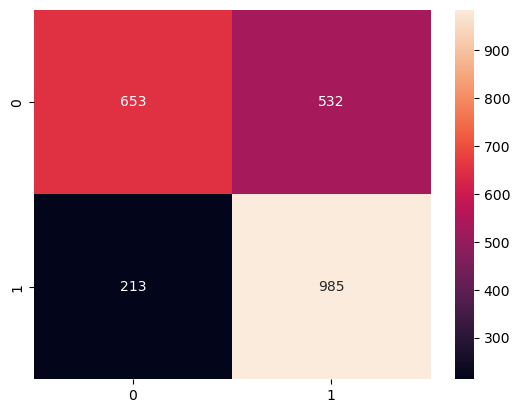

Training Decision Tree...
Decision Tree Classification Report
              precision    recall  f1-score   support

           0       0.71      0.66      0.68      1185
           1       0.69      0.73      0.71      1198

    accuracy                           0.69      2383
   macro avg       0.70      0.69      0.69      2383
weighted avg       0.70      0.69      0.69      2383



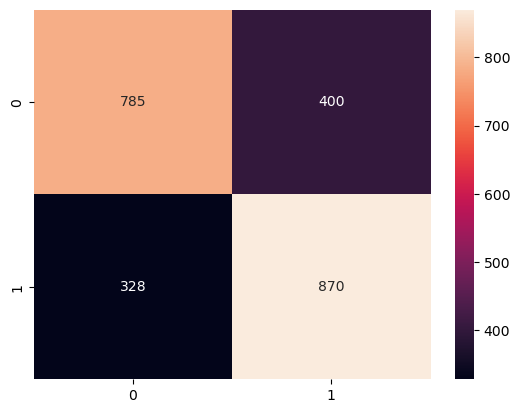

Training XGBoost...
XGBoost Classification Report
              precision    recall  f1-score   support

           0       0.74      0.90      0.81      1185
           1       0.87      0.68      0.76      1198

    accuracy                           0.79      2383
   macro avg       0.80      0.79      0.79      2383
weighted avg       0.81      0.79      0.79      2383



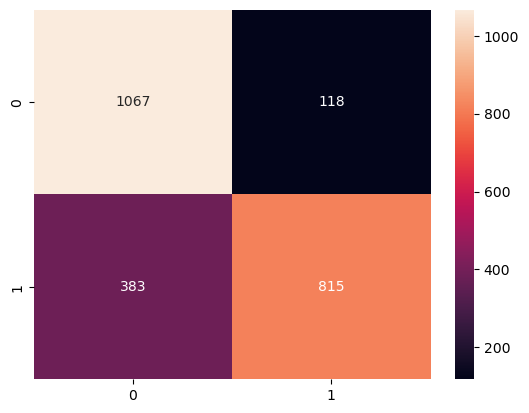

In [353]:
from sklearn.metrics import accuracy_score

results = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")

    # Model Training
    model.fit(x_train, y_train)

    # Predict on the test set
    y_pred = model.predict(x_test)

    # Evaluate the models
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    matrix = confusion_matrix(y_test, y_pred)

    # Stores results
    results[model_name] = {
        'accuracy': accuracy,
        'classification_report': report,
        'confusion matrix': matrix
    }

    print(f"{model_name} Classification Report")
    print(report)

    sns.heatmap(matrix, annot=True, fmt="g")
    
    # Clean filename
    safe_name = model_name.replace(" ", "_")

    # Save image
    plt.savefig(f"{safe_name}_confusion_matrix.png", bbox_inches="tight")

    plt.show()

### HYPER-PARAMETER TUNNING

In [354]:
# We are using Grid Search for hyperparameter tunning for random forest classifier
from sklearn.model_selection import GridSearchCV


In [355]:


# Define the parameter grid
parameter_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [356]:
# Initialize GridSearchCV
grid_search = GridSearchCV(RandomForestClassifier(random_state=42, class_weight="balanced"),
                           param_grid=parameter_grid,
                           scoring='f1',
                           cv=5,
                           n_jobs=-1
                )

In [357]:
# Fit the model
grid_search.fit(x_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [358]:
# Best Parameter
print(f"Best Hyperparameters : {grid_search.best_params_}")

Best Hyperparameters : {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [359]:
# Train Best Model
best_rf = grid_search.best_estimator_

In [360]:
y_pred_best_rf = best_rf.predict(x_test)

In [361]:
print("fine tuned random forest classifier")
report = classification_report(y_test, y_pred_best_rf)
print(report)

fine tuned random forest classifier
              precision    recall  f1-score   support

           0       0.79      0.88      0.83      1185
           1       0.86      0.77      0.81      1198

    accuracy                           0.82      2383
   macro avg       0.83      0.82      0.82      2383
weighted avg       0.83      0.82      0.82      2383



<function matplotlib.pyplot.show(close=None, block=None)>

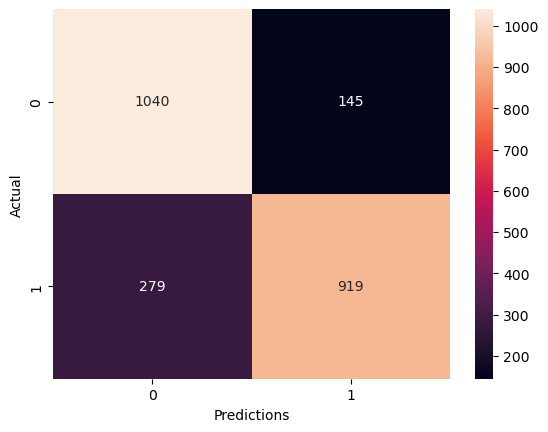

In [362]:
matrix = confusion_matrix(y_test, y_pred_best_rf)
sns.heatmap(matrix, annot=True, fmt="g")
plt.xlabel("Predictions")
plt.ylabel("Actual")

# Save image
plt.savefig("Tuned_Random_Forest_confusion_matrix.png", bbox_inches="tight")

plt.show

### ROC CURVE AND AUC SCORES

In [363]:
# ROC-AUC will be use to evaluate the model ability to distinguish between classes

In [364]:
from sklearn.metrics import roc_curve, roc_auc_score

In [365]:
# Compute the probabilities for ROC
y_probs = best_rf.predict_proba(x_test)[:, 1]

In [366]:
# ROC Curve
fpr, tpr, threshold = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

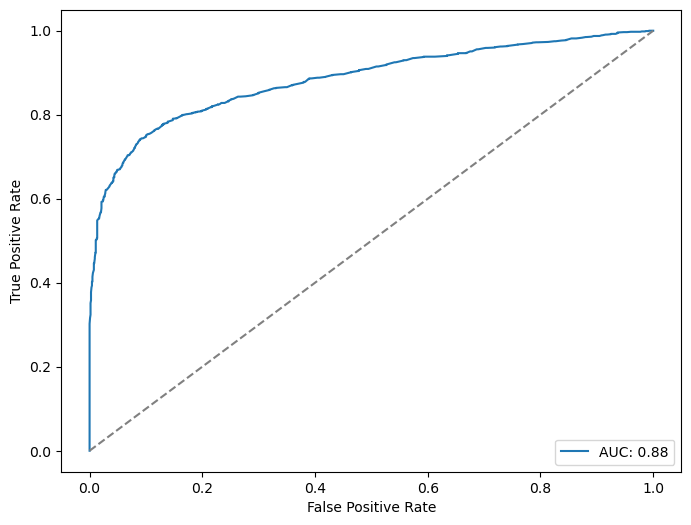

In [367]:
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"AUC: {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

plt.savefig("roc_curve.png", bbox_inches="tight")

plt.show()

In [368]:
import os
os.getcwd()

'C:\\Users\\sadeq'

In [369]:
!pip install -r requirements.txt